# Building a Convolutional Neural Network from Scratch

**Step 1 of 2: MNIST digit classification with a hand-built CNN**

In this notebook we build, train, and evaluate a convolutional neural network (CNN) on the classic **MNIST** dataset: 70,000 grayscale images of handwritten digits (0–9), each 28×28 pixels.

### Learning goals

By the end of this notebook you should be able to:

1. Explain what a **convolution** and a **pooling** operation do, and why they suit image data.
2. Read and modify a CNN definition in PyTorch.
3. Understand the anatomy of a **training loop**: forward pass → loss → backward pass → parameter update.
4. Evaluate a classifier with accuracy, a confusion matrix, and inspection of its errors.
5. **Experiment** with the architecture and observe how changes affect performance.

### A note on hardware

This notebook runs fine on a CPU, but a GPU makes it faster. In Google Colab: **Runtime → Change runtime type → T4 GPU**.


## 1. Setup

We import PyTorch (the deep learning framework), `torchvision` (datasets and image utilities), and some plotting tools.

A key habit in deep learning code: detect whether a **GPU** is available and store the answer in a `device` variable. Later we move both the model and each batch of data to that device.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt

# Reproducibility: fix the random seed so everyone gets (roughly) the same results.
torch.manual_seed(42)

# Use the GPU if one is available, otherwise fall back to the CPU.
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Using device: cuda


## 2. Loading the data

`torchvision` downloads MNIST for us and splits it into the standard **training set** (60,000 images) and **test set** (10,000 images). We never train on the test set — it exists solely to estimate how well the model generalizes to unseen data.

### Transforms

Each image arrives as a PIL image with pixel values 0–255. We apply two transformations:

- **`ToTensor()`** converts the image to a PyTorch tensor of shape `(1, 28, 28)` — that leading `1` is the number of **channels** (grayscale has one channel; a color image would have 3: red, green, blue) — and rescales pixels to the range [0, 1].
- **`Normalize(mean, std)`** standardizes the pixels using MNIST's known mean (0.1307) and standard deviation (0.3081). Just like standardizing predictors in a regression, this keeps the numbers in a well-behaved range and helps optimization converge.


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),                     # PIL image -> tensor in [0, 1], shape (1, 28, 28)
    transforms.Normalize((0.1307,), (0.3081,)) # standardize with MNIST's mean and std
])

train_data = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_data  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

print(f"Training images: {len(train_data):,}")
print(f"Test images:     {len(test_data):,}")

# Peek at one example: a (image, label) pair.
img, label = train_data[0]
print(f"One image has shape {tuple(img.shape)} and label {label}")


100%|██████████| 9.91M/9.91M [00:00<00:00, 61.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.65MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.4MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.8MB/s]

Training images: 60,000
Test images:     10,000
One image has shape (1, 28, 28) and label 5


### DataLoaders: feeding data in batches

Neural networks are trained with **mini-batch gradient descent**: instead of computing the loss over all 60,000 images at once, we process small random **batches** (here, 128 images at a time). Each batch gives a noisy but cheap estimate of the gradient.

A `DataLoader` handles the batching and shuffling for us. We shuffle the *training* data every epoch (so batches differ between passes) but not the test data (order doesn't matter there).


In [3]:
BATCH_SIZE = 128

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=256,        shuffle=False)

print(f"Batches per training epoch: {len(train_loader)}")


Batches per training epoch: 469


### Look at the data!

Always inspect your data before modeling. Note the variety of handwriting styles — this is exactly the kind of variation the network must learn to be robust to.

(The images look washed out because of the normalization; that's fine.)


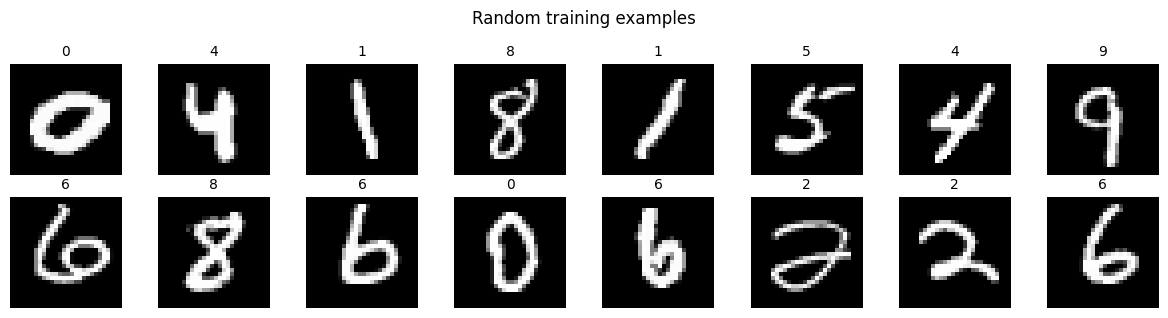

In [4]:
fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for ax in axes.flat:
    idx = np.random.randint(len(train_data))
    img, label = train_data[idx]
    ax.imshow(img.squeeze(), cmap="gray")   # squeeze() drops the channel dimension for plotting
    ax.set_title(str(label), fontsize=10)
    ax.axis("off")
plt.suptitle("Random training examples")
plt.tight_layout()
plt.show()


## 3. What is a convolutional neural network?

We *could* flatten each 28×28 image into a 784-dimensional vector and feed it to an ordinary feed-forward network. But that throws away the **spatial structure**: pixel (5, 5) is next to pixel (5, 6), and that adjacency matters.

CNNs exploit that structure with two key ideas:

### Convolutions
A **convolutional layer** slides a small filter (here 3×3) across the image. At every position it computes a weighted sum of the 3×3 patch of pixels underneath — the *same* weights at every position. Each filter learns to detect one local pattern: an edge at some orientation, a curve, a corner. With, say, 16 filters, the layer produces 16 **feature maps**, each highlighting where in the image its pattern occurs.

Two big wins over a fully connected layer:

- **Parameter sharing.** One 3×3 filter has just 9 weights, reused across the whole image. Detecting an edge in the top-left uses the same weights as detecting it in the bottom-right.
- **Locality.** Each output depends only on a small neighborhood, matching how image structure actually works.

### Pooling
A **max-pooling layer** downsamples each feature map by taking the maximum over small (2×2) windows, halving the width and height. This makes the representation more compact and a little **translation invariant**: the exact pixel position of a feature stops mattering, only its rough location does.

### The overall recipe
Stack `convolution → ReLU → pooling` blocks. Early layers detect simple patterns (edges); deeper layers combine them into complex ones (loops, digit parts). Finally, flatten and use ordinary fully connected layers to classify.

```
input (1×28×28)
  → conv(16 filters) → ReLU → pool   → (16×14×14)
  → conv(32 filters) → ReLU → pool   → (32×7×7)
  → flatten                          → (1568,)
  → fully connected → ReLU → dropout → (128,)
  → fully connected                  → (10,)   one score ("logit") per digit
```


## 4. A quick detour: why PyTorch, and what is a "class"?

If you have seen deep learning in **Keras**, you may know model-building as stacking layers into a `Sequential` container — a recipe you fill in. **PyTorch**, the framework we use here (and in the next notebook, because the Hugging Face ecosystem is built on it), takes a different stance: *you* write the model as ordinary Python code. That buys transparency — nothing happens that you can't see and print — and total flexibility, at the price of one piece of programming vocabulary: the **class**.

### Classes in one minute

Most code you have written is probably a sequence of function calls on data that sits in separate variables. A **class** bundles the two together: it is a blueprint that packages **data** (called *attributes*) with the **functions that operate on that data** (called *methods*). From one blueprint you can stamp out many concrete copies, called **instances** or *objects*.

You have been using classes all along without noticing. When you write `df = pd.DataFrame(...)`, `DataFrame` is a class; `df` is an instance of it; `df.shape` is an attribute (data stored inside `df`); `df.describe()` is a method (a function that acts on `df`'s own data). The dot means "reach inside this object."

A tiny example, unrelated to neural networks:

```python
class Student:
    def __init__(self, name):      # runs once, when the instance is created
        self.name = name           # store data ON the instance
        self.grades = []

    def add_grade(self, g):        # a method: a function attached to the instance
        self.grades.append(g)

    def average(self):
        return sum(self.grades) / len(self.grades)

alice = Student("Alice")           # calling the class creates an instance (runs __init__)
alice.add_grade(5.5)
alice.add_grade(6.0)
print(alice.average())             # 5.75
```

Three things to internalize:

- **`__init__`** is the *constructor*: it runs once when the instance is created and sets up its data.
- **`self`** is how the object refers to *itself*. Anything stored as `self.something` in `__init__` is available in every method later. (Python passes `self` automatically — you never supply it when calling.)
- **Inheritance** — `class Student(Person)` would mean: `Student` gets everything `Person` has, plus whatever it adds. The class in parentheses is the *parent*.

### Why is this the natural shape for a neural network?

A neural network is *exactly* a bundle of data plus behavior:

- **Data:** the learnable weights of every layer — these must persist between batches, because training means updating them.
- **Behavior:** the forward computation — how an input flows through those layers.

So in PyTorch a model is a class: `__init__` creates the layers (the data), `forward` defines the computation (the behavior). By writing `class SmallCNN(nn.Module)` we inherit from PyTorch's `nn.Module` parent class, which contributes all the machinery we'd rather not write ourselves: tracking every parameter (that's how `model.parameters()` knows what to hand the optimizer), moving them to the GPU with `.to(device)`, switching between `train()` and `eval()` modes, saving and loading. We supply the two parts that are unique to *our* model; `nn.Module` does the rest.

Keras has the same structure underneath — `Sequential` is a class too — it just hides the mechanics from you. PyTorch's bet, and the reason research and the Hugging Face world standardized on it, is that seeing the mechanics is worth it: in the next notebook we will reach inside a downloaded ResNet (`model.resnet`, `model.classifier`) and modify it — natural once a model is just a Python object with named attributes.

## 5. Defining the model

Now read the model definition below with the vocabulary in hand — it is the `Student` pattern, applied to a network:

- `__init__` declares the **layers** (which hold the learnable weights).
- `forward` says how data **flows** through them.

We deliberately expose the architecture as **arguments with defaults** (`n_filters1`, `n_filters2`, `hidden`, `dropout`) — this is what you will play with in the exercises.

One bookkeeping detail: after two rounds of pooling, the 28×28 image has shrunk to 7×7, so the flattened vector entering the first fully connected layer has `n_filters2 × 7 × 7` entries. If you change the pooling structure, you must update this number (exercise 5 walks you through it).

**Dropout** randomly zeroes a fraction of activations during training. It is a regularizer: because no single unit can be relied upon, the network is pushed to learn redundant, robust features — this combats overfitting.


In [5]:
class SmallCNN(nn.Module):
    def __init__(self, n_filters1=16, n_filters2=32, hidden=128, dropout=0.25):
        super().__init__()
        # Convolutional layers: (in_channels, out_channels, kernel_size).
        # padding=1 with a 3x3 kernel keeps width/height unchanged.
        self.conv1 = nn.Conv2d(1, n_filters1, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(n_filters1, n_filters2, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2)          # halves width and height
        self.dropout = nn.Dropout(dropout)

        # After two poolings: 28 -> 14 -> 7, so the flattened size is n_filters2 * 7 * 7.
        self.fc1 = nn.Linear(n_filters2 * 7 * 7, hidden)
        self.fc2 = nn.Linear(hidden, 10)     # 10 output scores, one per digit

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # (B, 1, 28, 28) -> (B, f1, 14, 14)
        x = self.pool(F.relu(self.conv2(x)))  # -> (B, f2, 7, 7)
        x = torch.flatten(x, 1)               # -> (B, f2*7*7); keep the batch dimension
        x = self.dropout(F.relu(self.fc1(x))) # -> (B, hidden)
        return self.fc2(x)                    # -> (B, 10) raw scores (logits)

model = SmallCNN().to(device)   # .to(device) moves the weights onto the GPU (if any)
print(model)


SmallCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


### How many parameters?

A useful sanity check. Notice where the parameters live: the convolutional layers are tiny (thanks to weight sharing), while the first fully connected layer dominates.


In [6]:
total = 0
for name, p in model.named_parameters():
    print(f"{name:15s} {str(tuple(p.shape)):18s} {p.numel():>9,}")
    total += p.numel()
print(f"{'TOTAL':15s} {'':18s} {total:>9,}")


conv1.weight    (16, 1, 3, 3)            144
conv1.bias      (16,)                     16
conv2.weight    (32, 16, 3, 3)         4,608
conv2.bias      (32,)                     32
fc1.weight      (128, 1568)          200,704
fc1.bias        (128,)                   128
fc2.weight      (10, 128)              1,280
fc2.bias        (10,)                     10
TOTAL                                206,922


## 6. Loss and optimizer

- **Loss — cross-entropy.** The model outputs 10 raw scores (**logits**). Cross-entropy converts them to probabilities (via softmax) and penalizes the model according to how little probability it put on the *correct* digit. It is the standard loss for classification — the deep-learning analogue of the negative log-likelihood you know from logit/probit models.
- **Optimizer — Adam.** Plain stochastic gradient descent updates each weight by `-learning_rate × gradient`. **Adam** is a refinement that adapts the step size per parameter; it is a robust default. The **learning rate** (here 0.001) is the single most important hyperparameter in deep learning: too high and training diverges, too low and it crawls.


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


## 7. The training loop

This is the heart of deep learning. One **epoch** = one full pass over the training data. For each batch we:

1. **Forward pass** — run the images through the model to get logits.
2. **Loss** — compare logits with the true labels.
3. **Backward pass** — `loss.backward()` computes the gradient of the loss with respect to *every* parameter (automatic differentiation / backpropagation).
4. **Update** — `optimizer.step()` nudges each parameter downhill; `optimizer.zero_grad()` clears the gradients for the next batch.

We wrap training and evaluation in functions so we can reuse them — *the exact same functions will train ResNet in the next notebook.*

Two easy-to-miss details:

- `model.train()` vs `model.eval()` switch the behavior of layers like dropout (active during training, off during evaluation).
- `torch.no_grad()` during evaluation tells PyTorch not to track gradients — faster and lighter on memory.


In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()                               # enable dropout etc.
    running_loss, correct, seen = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        logits = model(images)                  # 1. forward pass
        loss = criterion(logits, labels)        # 2. loss

        optimizer.zero_grad()                   # clear old gradients
        loss.backward()                         # 3. backward pass (compute gradients)
        optimizer.step()                        # 4. update parameters

        running_loss += loss.item() * len(labels)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        seen += len(labels)
    return running_loss / seen, correct / seen


@torch.no_grad()                                # no gradients needed for evaluation
def evaluate(model, loader, criterion, device):
    model.eval()                                # disable dropout etc.
    running_loss, correct, seen = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        running_loss += criterion(logits, labels).item() * len(labels)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        seen += len(labels)
    return running_loss / seen, correct / seen


### Train

Three epochs are enough to get well above 98% test accuracy. Watch both curves: if training accuracy keeps climbing while test accuracy stalls or falls, the model is **overfitting** — memorizing the training data rather than learning generalizable patterns.


In [9]:
EPOCHS = 3
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    te_loss, te_acc = evaluate(model, test_loader, criterion, device)
    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["test_loss"].append(te_loss);  history["test_acc"].append(te_acc)
    print(f"Epoch {epoch}: train loss {tr_loss:.4f}, train acc {tr_acc:.4f} | "
          f"test loss {te_loss:.4f}, test acc {te_acc:.4f}")


Epoch 1: train loss 0.2531, train acc 0.9225 | test loss 0.0680, test acc 0.9784
Epoch 2: train loss 0.0717, train acc 0.9786 | test loss 0.0405, test acc 0.9859
Epoch 3: train loss 0.0499, train acc 0.9847 | test loss 0.0351, test acc 0.9874


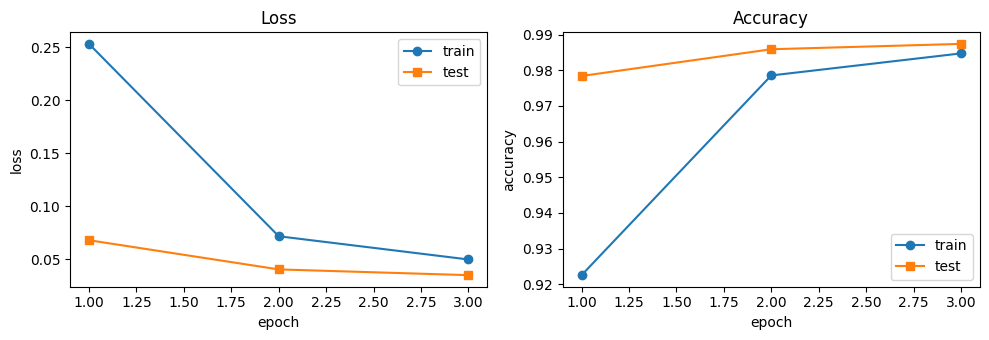

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
epochs = range(1, EPOCHS + 1)
ax1.plot(epochs, history["train_loss"], "o-", label="train")
ax1.plot(epochs, history["test_loss"], "s-", label="test")
ax1.set_xlabel("epoch"); ax1.set_ylabel("loss"); ax1.set_title("Loss"); ax1.legend()
ax2.plot(epochs, history["train_acc"], "o-", label="train")
ax2.plot(epochs, history["test_acc"], "s-", label="test")
ax2.set_xlabel("epoch"); ax2.set_ylabel("accuracy"); ax2.set_title("Accuracy"); ax2.legend()
plt.tight_layout()
plt.show()


## 8. Where does the model go wrong?

Overall accuracy hides structure. A **confusion matrix** cross-tabulates true digits (rows) against predicted digits (columns). The diagonal holds correct classifications; off-diagonal cells reveal *which* digits get confused with which — typically visually similar pairs like 4/9, 3/5, or 7/1.


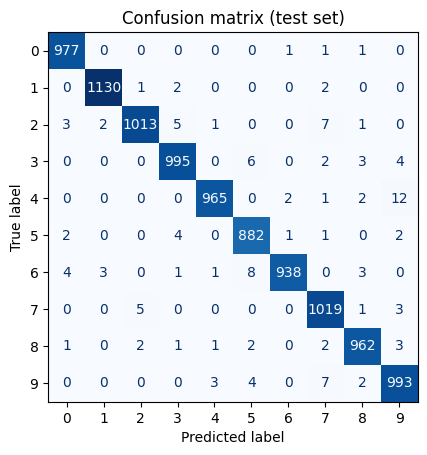

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Collect predictions for the whole test set.
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        logits = model(images.to(device))
        all_preds.append(logits.argmax(dim=1).cpu())
        all_labels.append(labels)
all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm).plot(cmap="Blues", colorbar=False)
plt.title("Confusion matrix (test set)")
plt.show()


### Look at the mistakes themselves

Inspecting misclassified images is often humbling: many are genuinely ambiguous, and you may disagree with the "true" label. This builds intuition for what the model finds hard — and for the irreducible noise in any labeling process.


126 of 10,000 test images misclassified


/tmp/ipykernel_486/1175358670.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


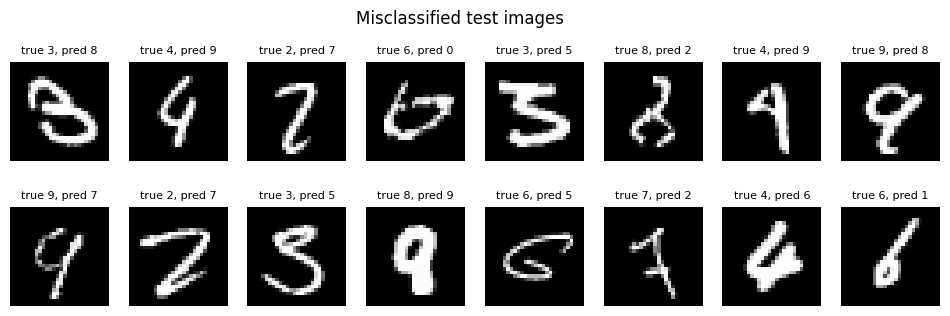

In [17]:
wrong = np.where(all_preds != all_labels)[0]
print(f"{len(wrong)} of {len(all_labels):,} test images misclassified")

fig, axes = plt.subplots(2, 8, figsize=(12, 3.6), gridspec_kw={'hspace': 0.1})
for ax, idx in zip(axes.flat, wrong[:16]):
    img, _ = test_data[idx]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"true {all_labels[idx]}, pred {all_preds[idx]}", fontsize=8)
    ax.axis("off")
plt.suptitle("Misclassified test images")
plt.tight_layout()
plt.show()

## 9. Peeking inside: what did the filters learn?

We can pass one image through just the first convolutional layer and plot the resulting feature maps. Different filters light up for different local patterns — some respond to strokes at particular orientations, others to background/foreground transitions. This is the "representation learning" that makes deep learning powerful: we never told the network what features to compute.


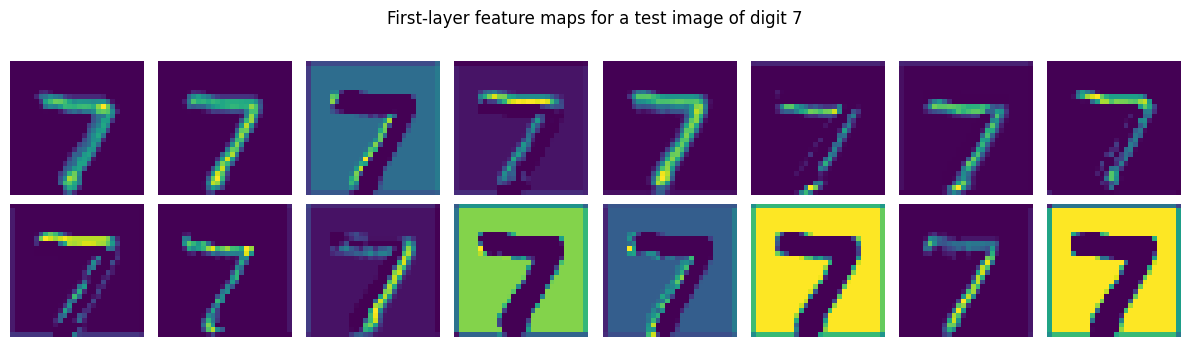

In [18]:
img, label = test_data[0]
with torch.no_grad():
    fmap = F.relu(model.conv1(img.unsqueeze(0).to(device)))  # (1, n_filters1, 28, 28)
fmap = fmap.squeeze(0).cpu()

n = fmap.shape[0]
fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(12, 3.6))
for i, ax in enumerate(axes.flat):
    if i < n:
        ax.imshow(fmap[i], cmap="viridis")
    ax.axis("off")
plt.suptitle(f"First-layer feature maps for a test image of digit {label}")
plt.tight_layout()
plt.show()


## 10. Your turn: experiment with the architecture

Because `SmallCNN` takes its architecture as arguments, experimenting is easy. The helper below builds a fresh model, trains it, and reports test accuracy — change the arguments and rerun.

**Suggested experiments** (predict the outcome *before* running!):

1. **Capacity ↓** — `n_filters1=4, n_filters2=8, hidden=32`. How much accuracy do you lose? How many parameters did you save?
2. **Capacity ↑** — `n_filters1=32, n_filters2=64, hidden=256`. Does more capacity help on a task this easy? What happens to the train/test gap?
3. **No dropout** — `dropout=0.0` and train for, say, 8 epochs. Watch for the training/test curves diverging (overfitting).
4. **Learning rate** — try `lr=0.1` and `lr=1e-5`. One will be unstable, the other painfully slow. This is why the learning rate is *the* hyperparameter to tune first.
5. **Harder (edit the class):** add a third `conv → ReLU → pool` block. Careful: 7 doesn't divide evenly by 2 — after a third pooling the maps are 3×3 (PyTorch floors the division), so the flattened size becomes `n_filters3 * 3 * 3`.
6. **Harder:** add `nn.BatchNorm2d(n_filters)` after each conv layer (before the ReLU). Batch normalization typically speeds up and stabilizes training.
